# 02 - Trend, seasonality, correlation and volatility

The brief names four things to look at before modelling. Each gets a section here, a chart, and a
sentence saying what follows from it. A chart with no sentence does not count.

Then a fifth section that the brief does not ask for and that decides the project: **is this a random
walk?** Every question above is really a way of asking that one, and it is worth asking directly, with a
test designed for it, before spending the effort of fitting anything.

The headline of this notebook is that the brief's third question has an obvious answer which is wrong by
a factor of four.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))

from src.data import load_clean
from src.diagnostics import adf_table, dayofweek_effect, ljung_box, variance_ratio_table
from src.plots import color, save, use_style

use_style()
pd.set_option("display.width", 130)

TEST_START = "2016-01-01"

clean = load_clean()
returns = np.log(clean).diff().dropna()

# The floating-rate window, established in notebook 01: before 2016 the yuan spends long periods
# pegged, and a statistic computed across a peg describes monetary policy rather than a market.
recent = clean.loc[TEST_START:]
recent_returns = returns.loc[TEST_START:]

print(f"full history      : {clean.index.min().date()} to {clean.index.max().date()}  ({len(clean):,} days)")
print(f"floating window   : {recent.index.min().date()} to {recent.index.max().date()}  ({len(recent):,} days)")

full history      : 2000-01-03 to 2019-12-31  (5,217 days)
floating window   : 2016-01-01 to 2019-12-31  (1,043 days)


## 1. Trend: both currencies weakened against the dollar, and that is not a forecastable trend

Remember the direction established in notebook 01: these series are **local currency per US dollar**, so
a falling line means the local currency getting *stronger*.

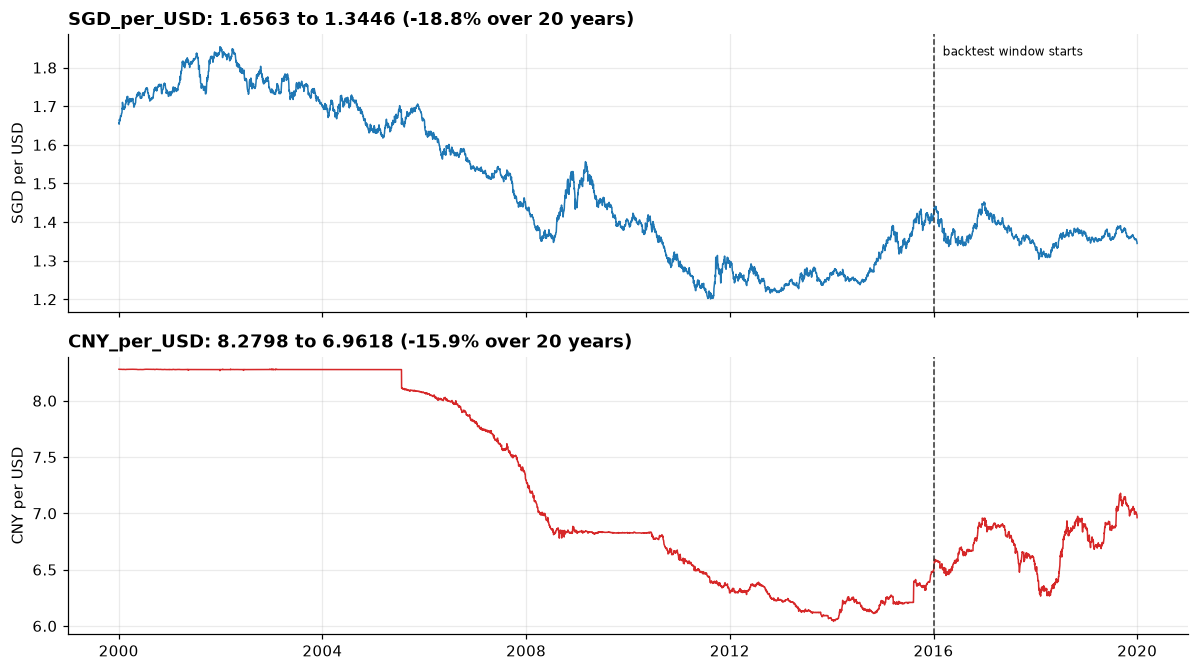

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6.2), sharex=True)

for ax, column in zip(axes, clean.columns):
    ax.plot(clean.index, clean[column], color=color(column), lw=1.0)
    ax.axvline(pd.Timestamp(TEST_START), color="#333333", ls="--", lw=1.0)
    ax.set_ylabel(column.replace("_", " "))
    total = 100 * (clean[column].iloc[-1] / clean[column].iloc[0] - 1)
    ax.set_title(f"{column}: {clean[column].iloc[0]:.4f} to {clean[column].iloc[-1]:.4f} "
                 f"({total:+.1f}% over 20 years)")

axes[0].annotate("backtest window starts", xy=(pd.Timestamp(TEST_START), axes[0].get_ylim()[1]),
                 xytext=(6, -14), textcoords="offset points", fontsize=8)
fig.tight_layout()
save(fig, "02_levels")
plt.show()

Both lines fall over twenty years: the Singapore dollar strengthened about 19 percent against the US
dollar, the yuan about 16 percent. A trend line drawn through either would fit well and would have been
useless in real time, which is the distinction the brief's word "trend" hides.

The reason is visible in the shape. Neither line is a slope with noise around it. Both are long stretches
of direction that reverse without warning: the yuan strengthens steadily for a decade and then weakens
for four years. That is what a random walk looks like at this scale, and it is why the trend question
cannot be answered with a regression on time. Section 5 makes this precise.

## 2. Seasonality: none, and the test for it is the direct one

For a daily exchange rate the only seasonal periods worth checking are the day of the week and the month.
Both are tested against zero rather than eyeballed, because a difference in means of a fraction of a basis
point is exactly the kind of thing a bar chart makes look real.

In [3]:
dow = {column: dayofweek_effect(recent_returns[column]) for column in returns.columns}
for column, table in dow.items():
    print(f"{column} (basis points per day, floating window)")
    print(table.round(3).to_string(index=False))
    print()

SGD_per_USD (basis points per day, floating window)
  weekday   n  mean_return_bp  std_bp  t_stat  p_value  significant_5pct
   Monday 209           0.928  25.115   0.534    0.594             False
  Tuesday 209          -0.611  26.850  -0.329    0.743             False
Wednesday 208          -0.726  26.200  -0.399    0.690             False
 Thursday 208          -2.266  38.052  -0.859    0.391             False
   Friday 209           0.164  30.372   0.078    0.938             False

CNY_per_USD (basis points per day, floating window)
  weekday   n  mean_return_bp  std_bp  t_stat  p_value  significant_5pct
   Monday 209           5.148  25.442   2.925    0.004              True
  Tuesday 209          -0.921  24.063  -0.553    0.581             False
Wednesday 208          -2.092  21.664  -1.392    0.165             False
 Thursday 208          -0.613  25.881  -0.342    0.733             False
   Friday 209           1.913  22.493   1.229    0.220             False



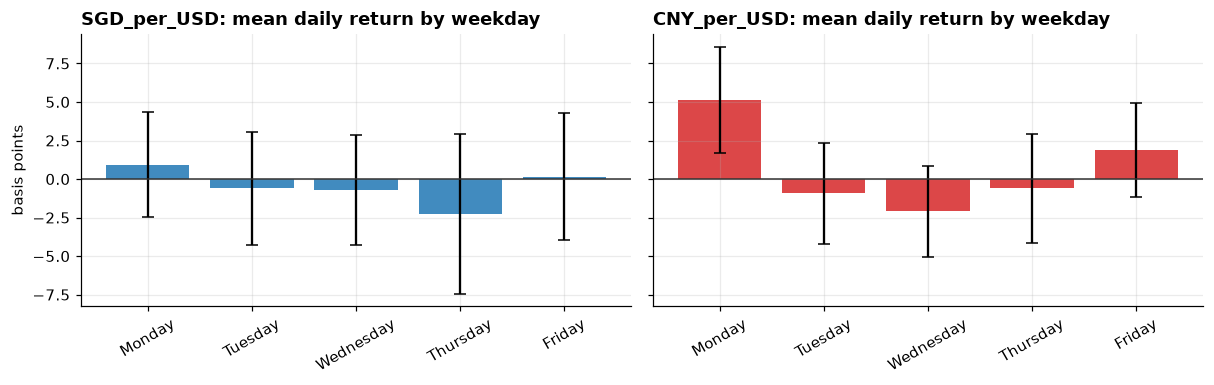

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)

for ax, (column, table) in zip(axes, dow.items()):
    error = 1.96 * table["std_bp"] / np.sqrt(table["n"])
    ax.bar(table["weekday"], table["mean_return_bp"], yerr=error, capsize=4,
           color=color(column), alpha=0.85)
    ax.axhline(0, color="#333333", lw=1.0)
    ax.set_title(f"{column}: mean daily return by weekday")
    ax.tick_params(axis="x", rotation=30)

axes[0].set_ylabel("basis points")
fig.tight_layout()
save(fig, "02_seasonality_dayofweek")
plt.show()

Every confidence interval crosses zero, on both currencies, on every weekday. The largest effect in the
table is Thursday on the Singapore dollar at -2.3 basis points with a standard error of 2.6, which is
noise with a name.

**Answer to the brief's seasonality question: there is none at a daily frequency.** This is not a
limitation of the search, it is the expected result. A weekday pattern in a currency traded around the
clock in the largest market in the world would be an arbitrage that pays a fixed sum every week, and it
would not survive being noticed.

The consequence is concrete and appears in notebook 03: **the seasonal terms in SARIMA have nothing to
model.** That model is run anyway, because "we tested it" is a stronger statement than "we assumed it",
but this section is where the outcome is already visible.

## 3. Correlation: the obvious answer is 0.96, and it is wrong

The brief asks whether the two rates move together. The obvious way to answer is to correlate the two
columns.

In [5]:
levels_corr_full = clean.corr().iloc[0, 1]
returns_corr_full = returns.corr().iloc[0, 1]
levels_corr_recent = recent.corr().iloc[0, 1]
returns_corr_recent = recent_returns.corr().iloc[0, 1]

comparison = pd.DataFrame(
    {
        "full history (2000-2019)": [levels_corr_full, returns_corr_full],
        "floating window (2016-2019)": [levels_corr_recent, returns_corr_recent],
    },
    index=["correlation of LEVELS", "correlation of DAILY RETURNS"],
)
comparison.round(4)

,full history (2000-2019),floating window (2016-2019)
correlation of LEVELS,0.9556,0.5573
correlation of DAILY RETURNS,0.2518,0.5220


**0.96 against 0.25.** The two numbers answer different questions and only one of them is the question
that was asked.

The correlation of the levels is high because both series drift downward over twenty years. Any two
series that trend in the same direction correlate strongly, whether or not they have anything to do with
each other: the classic demonstration correlates a country's cheese consumption with its number of
engineering doctorates and gets 0.96 as well. The statistic is measuring the shared trend, and since a
trend in a random walk is not a trend, it is measuring an accident of the sample.

The correlation of the daily returns is the answer to "do they move together": on any given day, when the
Singapore dollar moves, does the yuan move with it? Over the full history the answer is a weak yes, 0.25.

Note that the gap between the two closes in the floating window (0.56 against 0.52). That is not a
contradiction, it is the same explanation from the other side: over four years there is much less shared
trend for the level correlation to pick up.

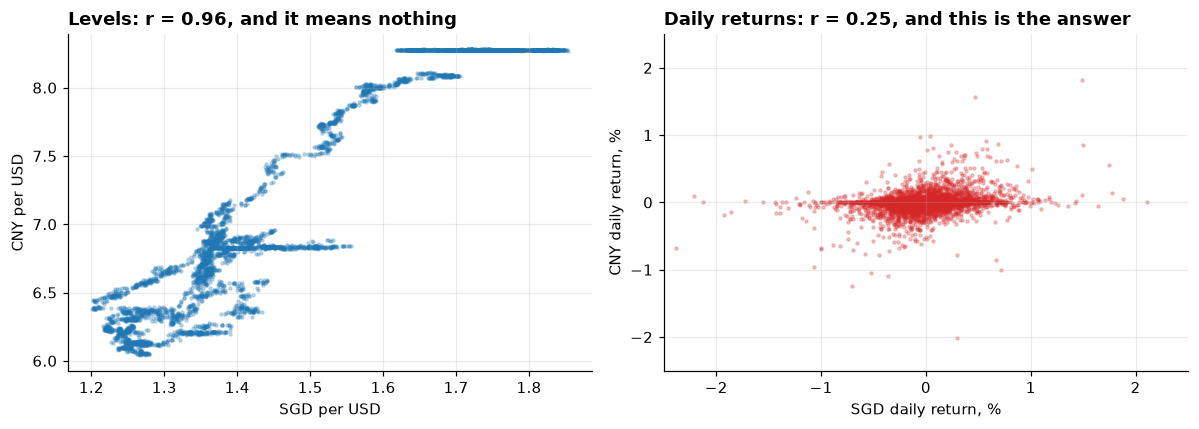

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))

axes[0].scatter(clean["SGD_per_USD"], clean["CNY_per_USD"], s=4, alpha=0.25, color="#1f77b4")
axes[0].set_title(f"Levels: r = {levels_corr_full:.2f}, and it means nothing")
axes[0].set_xlabel("SGD per USD")
axes[0].set_ylabel("CNY per USD")

axes[1].scatter(returns["SGD_per_USD"] * 100, returns["CNY_per_USD"] * 100, s=4, alpha=0.25,
                color="#d62728")
axes[1].set_title(f"Daily returns: r = {returns_corr_full:.2f}, and this is the answer")
axes[1].set_xlabel("SGD daily return, %")
axes[1].set_ylabel("CNY daily return, %")
axes[1].set_xlim(-2.5, 2.5)
axes[1].set_ylim(-2.5, 2.5)

fig.tight_layout()
save(fig, "02_correlation_levels_vs_returns")
plt.show()

The left panel is the shape that gives 0.96: a cloud following a diagonal band, which is two things
drifting together over two decades, with the pegged years showing as the dense vertical stripe at the top
where the yuan was constant while the Singapore dollar moved freely. The right panel is a round blob with
a faint tilt, which is what a correlation of 0.25 actually looks like.

Correlation also moves a great deal over time, so a single number for twenty years hides the answer even
when it is computed on the right quantity:

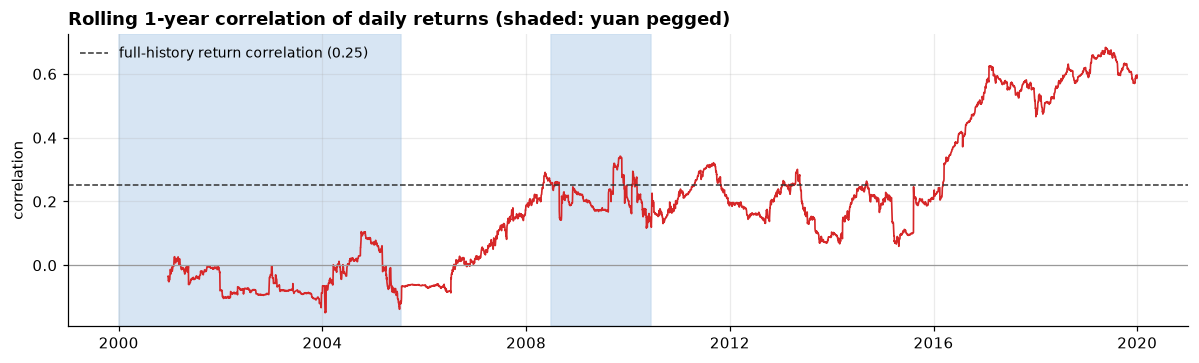

In [7]:
rolling_corr = returns["SGD_per_USD"].rolling(252).corr(returns["CNY_per_USD"])

fig, ax = plt.subplots(figsize=(11, 3.4))
ax.plot(rolling_corr.index, rolling_corr, color="#d62728", lw=1.1)
ax.axhline(returns_corr_full, color="#333333", ls="--", lw=1.0,
           label=f"full-history return correlation ({returns_corr_full:.2f})")
ax.axhline(0, color="#999999", lw=0.8)
ax.axvspan(clean.index.min(), pd.Timestamp("2005-07-21"), color="#c6dbef", alpha=0.7, zorder=0)
ax.axvspan(pd.Timestamp("2008-07-01"), pd.Timestamp("2010-06-18"), color="#c6dbef", alpha=0.7, zorder=0)
ax.set_title("Rolling 1-year correlation of daily returns (shaded: yuan pegged)")
ax.set_ylabel("correlation")
ax.legend(loc="upper left")
fig.tight_layout()
save(fig, "02_rolling_correlation")
plt.show()

Near zero for the whole first shaded block, which is correct and mechanical: a pegged currency cannot
co-move with anything, because it does not move. It rises after each liberalisation step and sits around
0.5 in the floating window.

**Answer to the brief's correlation question:** they move together moderately, around 0.5 today, and the
relationship is a function of Chinese exchange-rate policy rather than a stable property of the pair. The
practical consequence for the modelling is that each currency's lagged returns are offered to the other's
model as features in notebook 03, which is the honest way to let a model use this if it can.

## 4. Volatility: clustered, regime-dependent, and the one genuinely predictable thing here

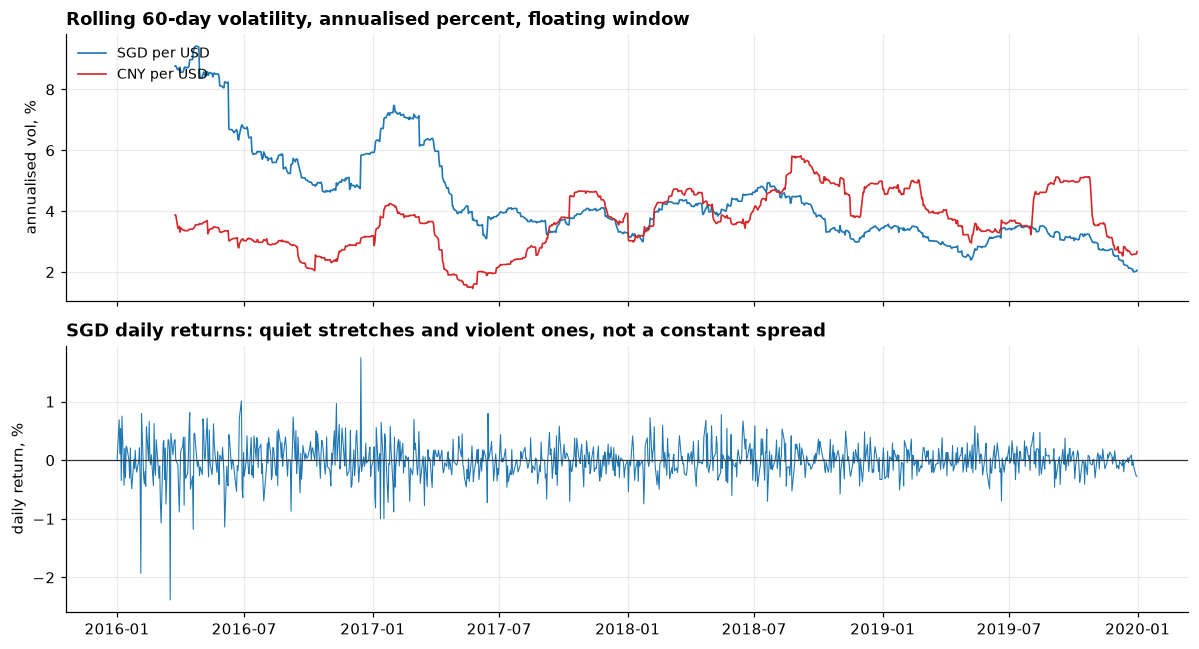

In [8]:
vol_60 = recent_returns.rolling(60).std() * np.sqrt(252) * 100

fig, axes = plt.subplots(2, 1, figsize=(11, 6.0), sharex=True)

for column in clean.columns:
    axes[0].plot(vol_60.index, vol_60[column], lw=1.1, color=color(column),
                 label=column.replace("_", " "))
axes[0].set_title("Rolling 60-day volatility, annualised percent, floating window")
axes[0].set_ylabel("annualised vol, %")
axes[0].legend(loc="upper left")

axes[1].plot(recent_returns.index, recent_returns["SGD_per_USD"] * 100, lw=0.7,
             color=color("SGD_per_USD"))
axes[1].axhline(0, color="#333333", lw=0.8)
axes[1].set_title("SGD daily returns: quiet stretches and violent ones, not a constant spread")
axes[1].set_ylabel("daily return, %")

fig.tight_layout()
save(fig, "02_volatility")
plt.show()

Volatility ranges from about 3 to 8 percent annualised inside four years and moves in blocks: calm
periods follow calm periods, violent days follow violent days. That is volatility clustering, and it is
worth testing rather than describing, because it turns out to be the sharpest statistical result in the
whole dataset.

The test is Ljung-Box, run twice on the same series. On the **returns** it asks whether the *direction*
of tomorrow's move is predictable from past moves. On the **squared returns** it asks whether its *size*
is.

In [9]:
rows = []
for column in returns.columns:
    plain = ljung_box(recent_returns[column], lags=10).iloc[0]
    squared = ljung_box(recent_returns[column], lags=10, squared=True).iloc[0]
    rows.append({
        "series": column,
        "LB on returns (direction)": plain["lb_stat"],
        "p": plain["lb_pvalue"],
        "LB on squared returns (size)": squared["lb_stat"],
        "p ": squared["lb_pvalue"],
    })
pd.DataFrame(rows).round(4)

,series,LB on returns (direction),p,LB on squared returns (size),p
0,SGD_per_USD,7.8402,0.6444,45.0279,0.0000
1,CNY_per_USD,13.5240,0.1958,23.7141,0.0084


**Direction: not predictable** (p = 0.64 and 0.20, both comfortably above 0.05, so no autocorrelation is
detected). **Size: strongly predictable** (p < 0.001 and p = 0.007).

This single table is the most useful thing in the notebook for a bank, and it is worth stating plainly
because it survives into the business conclusion: *whether* the rate will move is forecastable, *which
way* is not. A treasury desk cannot use this to take a position, and can absolutely use it to size a
hedge, set a margin, or decide which weeks need a wider risk limit.

## 5. The question underneath all four: is this a random walk?

Three tests, each attacking it from a different direction, all on the floating window.

In [10]:
print("Augmented Dickey-Fuller. Null hypothesis: the series has a unit root, i.e. it is a random walk.")
print()
print("On the levels:")
print(adf_table(recent).round(4).to_string(index=False))
print()
print("On the log returns:")
print(adf_table(recent, transform="log_returns").round(4).to_string(index=False))

Augmented Dickey-Fuller. Null hypothesis: the series has a unit root, i.e. it is a random walk.

On the levels:
     series transform  adf_stat  p_value  lags_used    n  crit_1pct  crit_5pct  unit_root_rejected_5pct
SGD_per_USD    levels   -2.5538   0.1029          0 1042    -3.4366    -2.8643                    False
CNY_per_USD    levels   -1.2031   0.6723          4 1038    -3.4367    -2.8643                    False

On the log returns:
     series   transform  adf_stat  p_value  lags_used    n  crit_1pct  crit_5pct  unit_root_rejected_5pct
SGD_per_USD log_returns  -33.1636      0.0          0 1041    -3.4366    -2.8643                     True
CNY_per_USD log_returns  -14.7935      0.0          3 1038    -3.4367    -2.8643                     True


On the levels the unit root cannot be rejected for either currency (p = 0.10 and 0.67). On the returns it
is rejected overwhelmingly (p < 0.001). That is the textbook signature of a series that is integrated of
order one: the rate itself is a random walk, its daily changes are stationary noise.

ADF is a weak test, though, and "cannot reject" is not "confirmed". The variance ratio test attacks the
same hypothesis directly and has more to say.

In [11]:
vr = variance_ratio_table(recent)
print("Lo-MacKinlay variance ratio, heteroskedasticity-robust.")
print("Under a random walk the q-period variance is q times the 1-period variance, so VR = 1.")
print("VR > 1 means moves persist (momentum). VR < 1 means they reverse (mean reversion).")
print()
print(vr.round(4).to_string(index=False))

Lo-MacKinlay variance ratio, heteroskedasticity-robust.
Under a random walk the q-period variance is q times the 1-period variance, so VR = 1.
VR > 1 means moves persist (momentum). VR < 1 means they reverse (mean reversion).

     series  q  variance_ratio  z_robust  p_value  random_walk_rejected_5pct
SGD_per_USD  2          0.9727   -0.6960   0.4864                      False
SGD_per_USD  5          0.8961   -1.2869   0.1981                      False
SGD_per_USD 10          0.8372   -1.3274   0.1844                      False
SGD_per_USD 21          0.7997   -1.0703   0.2845                      False
CNY_per_USD  2          0.9602   -1.0235   0.3061                      False
CNY_per_USD  5          1.0422    0.5072   0.6120                      False
CNY_per_USD 10          1.1815    1.4878   0.1368                      False
CNY_per_USD 21          1.4180    2.3901   0.0168                       True


Read the last two rows.

**Singapore dollar: a random walk at every horizon tested.** The ratios drift below 1 as the horizon
grows, hinting at very mild mean reversion, and not one of them is significant. There is no linear
structure here for ARIMA or for a tree to find.

**Chinese yuan at the monthly horizon: the random walk is rejected**, VR = 1.42 with p = 0.017. A ratio
above 1 means monthly moves are larger than twenty-one daily moves would imply, which is momentum: a yuan
that has been drifting one way tends to keep drifting that way for weeks. That is exactly what a *managed*
float should look like, since the central bank smooths day to day and lets the level walk over months.

This produces a falsifiable prediction, written down before the models are run:

> If any model in notebook 03 beats the naive forecast, it should be on **CNY at horizon 21**, and it
> should be a model that can carry directional momentum. Nothing should beat the naive forecast on SGD at
> horizon 1.

Notebook 03 checks that against a thousand forecast origins.

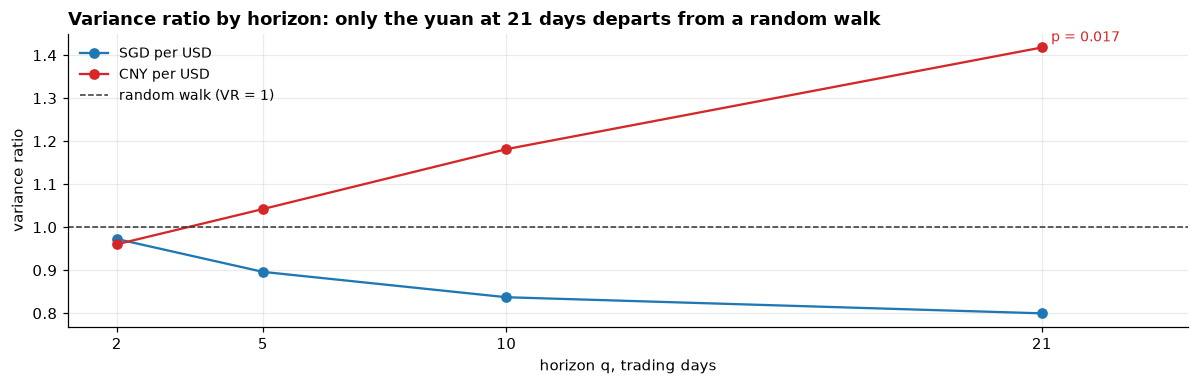

In [12]:
fig, ax = plt.subplots(figsize=(11, 3.6))

for column in recent.columns:
    block = vr[vr["series"] == column]
    ax.plot(block["q"], block["variance_ratio"], marker="o", color=color(column),
            label=column.replace("_", " "))
    for _, row in block[block["random_walk_rejected_5pct"]].iterrows():
        ax.annotate(f"p = {row['p_value']:.3f}", xy=(row["q"], row["variance_ratio"]),
                    xytext=(6, 4), textcoords="offset points", fontsize=9, color=color(column))

ax.axhline(1.0, color="#333333", ls="--", lw=1.0, label="random walk (VR = 1)")
ax.set_xlabel("horizon q, trading days")
ax.set_ylabel("variance ratio")
ax.set_title("Variance ratio by horizon: only the yuan at 21 days departs from a random walk")
ax.set_xticks(sorted(vr["q"].unique()))
ax.set_xlim(1, max(vr["q"]) + 3)   # room for the annotation on the last point
ax.legend(loc="upper left")
fig.tight_layout()
save(fig, "02_variance_ratio")
plt.show()

## What this notebook establishes

| Brief's question | Answer | Evidence |
|---|---|---|
| Trend | Both currencies strengthened against the dollar over 20 years, but the path is a random walk, so the trend is not extrapolable | Level charts, and section 5 |
| Seasonality | None at daily frequency, on either currency, on any weekday | Every confidence interval crosses zero |
| Correlation | Moderate, about 0.5 today, and driven by Chinese policy. **Not** the 0.96 the levels report | Return correlation against level correlation, rolling window |
| Volatility | Strongly clustered and regime-dependent. Its size is predictable while its direction is not | Ljung-Box on returns against squared returns |
| *Is it a random walk?* | Yes for SGD at every horizon. No for CNY at 21 days, where momentum is significant | ADF, variance ratio |

The one number to carry forward: **the direction of tomorrow's move shows no detectable autocorrelation,
and the size of it shows a great deal.** Everything in notebook 03 is an attempt to beat that first fact,
and the business conclusion rests on the second.

Next: `03_backtest_models_vs_random_walk.ipynb`.